In [1]:
import os
import glob
import yaml
import torch
import argparse
import numpy as np
import torchvision
from torchvision import transforms, datasets
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from torch import nn
from torch.optim import Adam
from torch.utils.data import  DataLoader

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
class LinearNoiseScheduler:
    r"""
    Class for the linear noise scheduler that is used in DDPM.
    """
    def __init__(self, num_timesteps, beta_start, beta_end):
        self.num_timesteps = num_timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end

        self.betas = torch.linspace(beta_start, beta_end, num_timesteps)
        self.alphas = 1. - self.betas
        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_cum_prod = torch.sqrt(self.alpha_cum_prod)
        self.sqrt_one_minus_alpha_cum_prod = torch.sqrt(1 - self.alpha_cum_prod)

    def add_noise(self, original, noise, t):
        r"""
        Forward method for diffusion
        :param original: Image on which noise is to be applied
        :param noise: Random Noise Tensor (from normal dist)
        :param t: timestep of the forward process of shape -> (B,)
        :return:
        """
        original_shape = original.shape
        batch_size = original_shape[0]

        sqrt_alpha_cum_prod = self.sqrt_alpha_cum_prod.to(original.device)[t].reshape(batch_size)
        sqrt_one_minus_alpha_cum_prod = self.sqrt_one_minus_alpha_cum_prod.to(original.device)[t].reshape(batch_size)

        for _ in range(len(original_shape) - 1):
            sqrt_alpha_cum_prod = sqrt_alpha_cum_prod.unsqueeze(-1)
        for _ in range(len(original_shape) - 1):
            sqrt_one_minus_alpha_cum_prod = sqrt_one_minus_alpha_cum_prod.unsqueeze(-1)

        return (
            sqrt_alpha_cum_prod.to(original.device) * original
            + sqrt_one_minus_alpha_cum_prod.to(original.device) * noise
        )

    def sample_prev_timestep(self, xt, noise_pred, t):
        r"""
        Use the noise prediction by model to get xt-1 using xt and the noise predicted
        :param xt: current timestep sample
        :param noise_pred: model noise prediction
        :param t: current timestep we are at
        :return:
        """
        x0 = (
            (xt - (self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t] * noise_pred))
            / torch.sqrt(self.alpha_cum_prod.to(xt.device)[t])
        )
        x0 = torch.clamp(x0, -1., 1.)

        mean = xt - (
            (self.betas.to(xt.device)[t]) * noise_pred
        ) / (self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t])
        mean = mean / torch.sqrt(self.alphas.to(xt.device)[t])

        if t == 0:
            return mean, x0
        else:
            variance = (
                (1 - self.alpha_cum_prod.to(xt.device)[t - 1])
                / (1.0 - self.alpha_cum_prod.to(xt.device)[t])
            )
            variance = variance * self.betas.to(xt.device)[t]
            sigma = variance ** 0.5
            z = torch.randn(xt.shape).to(xt.device)
            return mean + sigma * z, x0


In [4]:
def get_time_embedding(time_steps, temb_dim):
    r"""
    Convert time steps tensor into an embedding using the
    sinusoidal time embedding formula
    :param time_steps: 1D tensor of length batch size
    :param temb_dim: Dimension of the embedding
    :return: BxD embedding representation of B time steps
    """
    assert temb_dim % 2 == 0, "time embedding dimension must be divisible by 2"

    factor = 10000 ** (
        torch.arange(
            start=0,
            end=temb_dim // 2,
            dtype=torch.float32,
            device=time_steps.device
        ) / (temb_dim // 2)
    )

    t_emb = time_steps[:, None].repeat(1, temb_dim // 2) / factor
    t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], dim=-1)
    return t_emb


In [5]:
class DownBlock(nn.Module):
    r"""
    Down conv block with attention.
    Sequence:
    1. Resnet block with time embedding
    2. Attention block
    3. Downsample
    """
    def __init__(self, in_channels, out_channels, t_emb_dim,
                 down_sample=True, num_heads=4, num_layers=1):
        super().__init__()
        self.num_layers = num_layers
        self.down_sample = down_sample

        self.resnet_conv_first = nn.ModuleList([
            nn.Sequential(
                nn.GroupNorm(8, in_channels if i == 0 else out_channels),
                nn.SiLU(),
                nn.Conv2d(
                    in_channels if i == 0 else out_channels,
                    out_channels,
                    kernel_size=3,
                    stride=1,
                    padding=1
                ),
            )
            for i in range(num_layers)
        ])

        self.t_emb_layers = nn.ModuleList([
            nn.Sequential(
                nn.SiLU(),
                nn.Linear(t_emb_dim, out_channels)
            )
            for _ in range(num_layers)
        ])

        self.resnet_conv_second = nn.ModuleList([
            nn.Sequential(
                nn.GroupNorm(8, out_channels),
                nn.SiLU(),
                nn.Conv2d(
                    out_channels,
                    out_channels,
                    kernel_size=3,
                    stride=1,
                    padding=1
                ),
            )
            for _ in range(num_layers)
        ])

        self.attention_norms = nn.ModuleList([
            nn.GroupNorm(8, out_channels) for _ in range(num_layers)
        ])

        self.attentions = nn.ModuleList([
            nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
            for _ in range(num_layers)
        ])

        self.residual_input_conv = nn.ModuleList([
            nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
            for i in range(num_layers)
        ])

        self.down_sample_conv = (
            nn.Conv2d(out_channels, out_channels, 4, 2, 1)
            if self.down_sample else nn.Identity()
        )

    def forward(self, x, t_emb):
        out = x
        for i in range(self.num_layers):
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)

            batch_size, channels, h, w = out.shape
            in_attn = self.attention_norms[i](out)
            in_attn = in_attn.reshape(batch_size, channels, h * w)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn

        out = self.down_sample_conv(out)
        return out

In [6]:
class MidBlock(nn.Module):
    r"""
    Mid conv block with attention.
    Sequence:
    1. Resnet block with time embedding
    2. Attention block
    3. Resnet block with time embedding
    """
    def __init__(self, in_channels, out_channels, t_emb_dim, num_heads=4, num_layers=1):
        super().__init__()
        self.num_layers = num_layers

        self.resnet_conv_first = nn.ModuleList([
            nn.Sequential(
                nn.GroupNorm(8, in_channels if i == 0 else out_channels),
                nn.SiLU(),
                nn.Conv2d(
                    in_channels if i == 0 else out_channels,
                    out_channels,
                    kernel_size=3,
                    stride=1,
                    padding=1
                ),
            )
            for i in range(num_layers + 1)
        ])

        self.t_emb_layers = nn.ModuleList([
            nn.Sequential(
                nn.SiLU(),
                nn.Linear(t_emb_dim, out_channels)
            )
            for _ in range(num_layers + 1)
        ])

        self.resnet_conv_second = nn.ModuleList([
            nn.Sequential(
                nn.GroupNorm(8, out_channels),
                nn.SiLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            )
            for _ in range(num_layers + 1)
        ])

        self.attention_norms = nn.ModuleList([
            nn.GroupNorm(8, out_channels) for _ in range(num_layers)
        ])

        self.attentions = nn.ModuleList([
            nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
            for _ in range(num_layers)
        ])

        self.residual_input_conv = nn.ModuleList([
            nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
            for i in range(num_layers + 1)
        ])

    def forward(self, x, t_emb):
        out = x

        resnet_input = out
        out = self.resnet_conv_first[0](out)
        out = out + self.t_emb_layers[0](t_emb)[:, :, None, None]
        out = self.resnet_conv_second[0](out)
        out = out + self.residual_input_conv[0](resnet_input)

        for i in range(self.num_layers):
            batch_size, channels, h, w = out.shape
            in_attn = self.attention_norms[i](out)
            in_attn = in_attn.reshape(batch_size, channels, h * w)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn

            resnet_input = out
            out = self.resnet_conv_first[i + 1](out)
            out = out + self.t_emb_layers[i + 1](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i + 1](out)
            out = out + self.residual_input_conv[i + 1](resnet_input)

        return out

In [7]:
class UpBlock(nn.Module):
    r"""
    Up conv block with attention.
    Sequence:
    1. Upsample
    2. Concatenate Down block output
    3. Resnet block with time embedding
    4. Attention block
    """
    def __init__(self, in_channels, out_channels, t_emb_dim, up_sample=True, num_heads=4, num_layers=1):
        super().__init__()
        self.num_layers = num_layers
        self.up_sample = up_sample

        self.resnet_conv_first = nn.ModuleList([
            nn.Sequential(
                nn.GroupNorm(8, in_channels if i == 0 else out_channels),
                nn.SiLU(),
                nn.Conv2d(
                    in_channels if i == 0 else out_channels,
                    out_channels,
                    kernel_size=3,
                    stride=1,
                    padding=1
                ),
            )
            for i in range(num_layers)
        ])

        self.t_emb_layers = nn.ModuleList([
            nn.Sequential(
                nn.SiLU(),
                nn.Linear(t_emb_dim, out_channels)
            )
            for _ in range(num_layers)
        ])

        self.resnet_conv_second = nn.ModuleList([
            nn.Sequential(
                nn.GroupNorm(8, out_channels),
                nn.SiLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            )
            for _ in range(num_layers)
        ])

        self.attention_norms = nn.ModuleList([
            nn.GroupNorm(8, out_channels) for _ in range(num_layers)
        ])

        self.attentions = nn.ModuleList([
            nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
            for _ in range(num_layers)
        ])

        self.residual_input_conv = nn.ModuleList([
            nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
            for i in range(num_layers)
        ])

        self.up_sample_conv = (
            nn.ConvTranspose2d(in_channels //2 , in_channels //2, 4, 2, 1)
            if self.up_sample else nn.Identity()
        )

    def forward(self, x, out_down, t_emb):
        x = self.up_sample_conv(x)
        x = torch.cat([x, out_down], dim=1)

        out = x
        for i in range(self.num_layers):
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)

            batch_size, channels, h, w = out.shape
            in_attn = self.attention_norms[i](out)
            in_attn = in_attn.reshape(batch_size, channels, h * w)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn

        return out

In [8]:
class Unet(nn.Module):
    r"""
    Unet model comprising
    Down blocks, Midblocks and Uplocks
    """
    def __init__(self, model_config):
        super().__init__()
        im_channels = model_config['im_channels']
        self.down_channels = model_config['down_channels']
        self.mid_channels = model_config['mid_channels']
        self.t_emb_dim = model_config['time_emb_dim']
        self.down_sample = model_config['down_sample']
        self.num_down_layers = model_config['num_down_layers']
        self.num_mid_layers = model_config['num_mid_layers']
        self.num_up_layers = model_config['num_up_layers']

        assert self.mid_channels[0] == self.down_channels[-1]
        assert self.mid_channels[-1] == self.down_channels[-2]
        assert len(self.down_sample) == len(self.down_channels) - 1

        self.t_proj = nn.Sequential(
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim)
        )

        self.up_sample = list(reversed(self.down_sample))
        self.conv_in = nn.Conv2d(im_channels, self.down_channels[0], kernel_size=3, padding=1)

        self.downs = nn.ModuleList([])
        for i in range(len(self.down_channels) - 1):
            self.downs.append(
                DownBlock(
                    self.down_channels[i],
                    self.down_channels[i + 1],
                    self.t_emb_dim,
                    down_sample=self.down_sample[i],
                    num_layers=self.num_down_layers
                )
            )

        self.mids = nn.ModuleList([])
        for i in range(len(self.mid_channels) - 1):
            self.mids.append(
                MidBlock(
                    self.mid_channels[i],
                    self.mid_channels[i + 1],
                    self.t_emb_dim,
                    num_layers=self.num_mid_layers
                )
            )

        self.ups = nn.ModuleList([])
        for i in reversed(range(len(self.down_channels) - 1)):
            self.ups.append(
                UpBlock(
                    self.down_channels[i] * 2,
                    self.down_channels[i - 1] if i != 0 else 16,
                    self.t_emb_dim,
                    up_sample=self.down_sample[i],
                    num_layers=self.num_up_layers
                )
            )

        self.norm_out = nn.GroupNorm(8, 16)
        self.conv_out = nn.Conv2d(16, im_channels, kernel_size=3, padding=1)

    def forward(self, x, t):
        out = self.conv_in(x)

        t = torch.as_tensor(t, device=x.device).long()
        t_emb = get_time_embedding(t, self.t_emb_dim)
        t_emb = self.t_proj(t_emb)

        down_outs = []

        for down in self.downs:
            down_outs.append(out)
            out = down(out, t_emb)

        for mid in self.mids:
            out = mid(out, t_emb)

        for up in self.ups:
            down_out = down_outs.pop()
            out = up(out, down_out, t_emb)

        out = self.norm_out(out)
        out = nn.SiLU()(out)
        out = self.conv_out(out)
        return out

In [9]:
def sample(model, scheduler, train_config, model_config, diffusion_config, save_steps=False):
    """
    Sample stepwise by going backward one timestep at a time.
    """
    model.eval()

    xt = torch.randn(
        (
            train_config['num_samples'],
            model_config['im_channels'],
            model_config['im_size'],
            model_config['im_size']
        )
    ).to(device)

    if save_steps:
        os.makedirs(os.path.join(train_config['task_name'], 'samples'), exist_ok=True)

    with torch.no_grad():
        for i in tqdm(reversed(range(diffusion_config['num_timesteps'])), desc="Sampling"):
            t = torch.full((xt.shape[0],), i, device=device, dtype=torch.long)

            # predict noise
            noise_pred = model(xt, t)

            # scheduler step
            xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))

            if save_steps:
                ims = torch.clamp(xt, -1., 1.).detach().cpu()
                ims = (ims + 1) / 2
                grid = make_grid(ims, nrow=train_config['num_grid_rows'])
                img = torchvision.transforms.ToPILImage()(grid)
                img.save(os.path.join(train_config['task_name'], 'samples', f'x0_{i}.png'))
                img.close()

    model.train()
    return xt


In [10]:
def infer(config):
    diffusion_config = config['diffusion_params']
    model_config = config['model_params']
    train_config = config['train_params']

    model = Unet(model_config).to(device)

    ckpt_path = os.path.join(train_config['task_name'], train_config['ckpt_name'])
    checkpoint = torch.load(ckpt_path, map_location=device)

    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        model.load_state_dict(checkpoint["model_state"])
    else:
        model.load_state_dict(checkpoint)

    model.eval()

    scheduler = LinearNoiseScheduler(
        num_timesteps=diffusion_config['num_timesteps'],
        beta_start=diffusion_config['beta_start'],
        beta_end=diffusion_config['beta_end']
    )

    with torch.no_grad():
        samples = sample(model, scheduler, train_config, model_config, diffusion_config, save_steps=False)

    show_tensor_images(samples, nrow=train_config['num_grid_rows'], title="Generated Samples")
    return samples

In [11]:
def sample_and_show(model, scheduler, train_config, model_config, diffusion_config, title="Generated Images"):
    model.eval()

    xt = torch.randn(
        (
            train_config['num_samples'],
            model_config['im_channels'],
            model_config['im_size'],
            model_config['im_size']
        ),
        device=device
    )

    with torch.no_grad():
        for i in reversed(range(diffusion_config['num_timesteps'])):
            t = torch.full((xt.shape[0],), i, device=device, dtype=torch.long)
            noise_pred = model(xt, t)
            xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))

    show_tensor_images(xt, nrow=train_config['num_grid_rows'], title=title)
    model.train()


In [12]:
def show_tensor_images(images, nrow=8, title=None):
    images = torch.clamp(images, -1., 1.).detach().cpu()
    images = (images + 1) / 2
    grid = make_grid(images, nrow=nrow)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

In [13]:
def train(config, is_hybrid=False):
    print(f"Using device: {device}")

    diffusion_config = config['diffusion_params']
    model_config = config['model_params']
    train_config = config['train_params']

    # dataset
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: (2 * x) - 1)
    ])

    train_dataset = torchvision.datasets.MNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=train_config['batch_size'],
        shuffle=True,
        num_workers=2,
        pin_memory=True if device.type == 'cuda' else False
    )

    # model, scheduler, optimizer
    model = Unet(model_config).to(device)
    scheduler = LinearNoiseScheduler(
        num_timesteps=diffusion_config['num_timesteps'],
        beta_start=diffusion_config['beta_start'],
        beta_end=diffusion_config['beta_end']
    )
    optimizer = Adam(model.parameters(), lr=train_config['lr'])

    # checkpoint paths
    ckpt_dir = train_config['task_name']
    os.makedirs(ckpt_dir, exist_ok=True)

    latest_ckpt_path = os.path.join(ckpt_dir, train_config['ckpt_name'])

    print(f"Checkpoint directory: {ckpt_dir}")
    print(f"Latest checkpoint path: {latest_ckpt_path}")

    # resume if exists
    start_epoch = 0
    if os.path.exists(latest_ckpt_path):
        print(f"Loading checkpoint from: {latest_ckpt_path}")
        checkpoint = torch.load(latest_ckpt_path, map_location=device)

        if isinstance(checkpoint, dict) and 'model_state' in checkpoint:
            model.load_state_dict(checkpoint['model_state'])
            if 'optimizer_state' in checkpoint:
                optimizer.load_state_dict(checkpoint['optimizer_state'])
            start_epoch = checkpoint.get('step', -1) + 1
            print(f"Resuming training from epoch {start_epoch + 1}")
        else:
            model.load_state_dict(checkpoint)
            print("Loaded old-format checkpoint (model state_dict only). Starting from epoch 1.")
    else:
        print("No checkpoint found. Starting training from scratch.")

    # training loop
    for epoch_idx in range(start_epoch, train_config['num_epochs']):
        model.train()
        losses = []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch_idx + 1}/{train_config['num_epochs']}")
        for images, _ in pbar:
            images = images.to(device)

            noise = torch.randn_like(images).to(device)
            t = torch.randint(
                0,
                diffusion_config['num_timesteps'],
                (images.shape[0],),
                device=device
            ).long()

            noisy_images = scheduler.add_noise(images, noise, t)
            noise_pred = model(noisy_images, t)
            if not is_hybrid:
                loss = torch.nn.functional.mse_loss(noise_pred, noise)
            else:
                loss = loss = hybrid_noise_x0_loss(noise_pred, noise, noisy_images, images, t, scheduler)
                
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
            losses.append(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_loss = sum(losses) / len(losses)
        print(f"Epoch {epoch_idx + 1} finished - Avg Loss: {avg_loss:.4f}")

        # save checkpoint every epoch
        step = epoch_idx + 1
        epoch_ckpt_path = os.path.join(ckpt_dir, f"checkpoint_step{step}.pt")

        checkpoint_data = {
            "step": epoch_idx,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "loss": avg_loss
        }

        torch.save(checkpoint_data, epoch_ckpt_path)
        torch.save(checkpoint_data, latest_ckpt_path)

        print(f"Saved checkpoint: {epoch_ckpt_path}")
        print(f"Updated latest checkpoint: {latest_ckpt_path}")

        # generate images every 4 epochs only
        if (epoch_idx + 1) % 4 == 0:
            sample_and_show(
                model,
                scheduler,
                train_config,
                model_config,
                diffusion_config,
                title=f"Generated Images - Epoch {epoch_idx + 1}"
            )

    print("Training completed.")
    return model

In [14]:
config = {
    'diffusion_params': {
        'num_timesteps': 1000,
        'beta_start': 0.0001,
        'beta_end': 0.02
    },

    'model_params': {
        'im_channels': 1,
        'im_size': 28,
        'down_channels': [32, 64, 128, 256],
        'mid_channels': [256, 256, 128],
        'down_sample': [True, True, False],
        'time_emb_dim': 128,
        'num_down_layers': 2,
        'num_mid_layers': 2,
        'num_up_layers': 2,
        'num_heads': 4
    },

    'train_params': {
        'task_name': 'default',
        'batch_size': 64,
        'num_epochs': 20,
        'num_samples': 100,
        'num_grid_rows': 10,
        'lr': 0.0001,
        'ckpt_name': 'latest_checkpoint.pt'
    }
}

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 27.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.18MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.9MB/s]


Checkpoint directory: default
Latest checkpoint path: default/latest_checkpoint.pt
No checkpoint found. Starting training from scratch.


Epoch 1/20: 100%|██████████| 938/938 [06:01<00:00,  2.60it/s, loss=0.0271]


Epoch 1 finished - Avg Loss: 0.1024
Saved checkpoint: default/checkpoint_step1.pt
Updated latest checkpoint: default/latest_checkpoint.pt


...

Epoch 2 finished - Avg Loss: 0.0354
Saved checkpoint: default/checkpoint_step2.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 3/20: 100%|██████████| 938/938 [06:07<00:00,  2.55it/s, loss=0.0402]


Epoch 3 finished - Avg Loss: 0.0305
Saved checkpoint: default/checkpoint_step3.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 4/20: 100%|██████████| 938/938 [06:06<00:00,  2.56it/s, loss=0.0312]


Epoch 4 finished - Avg Loss: 0.0282
Saved checkpoint: default/checkpoint_step4.pt
Updated latest checkpoint: default/latest_checkpoint.pt


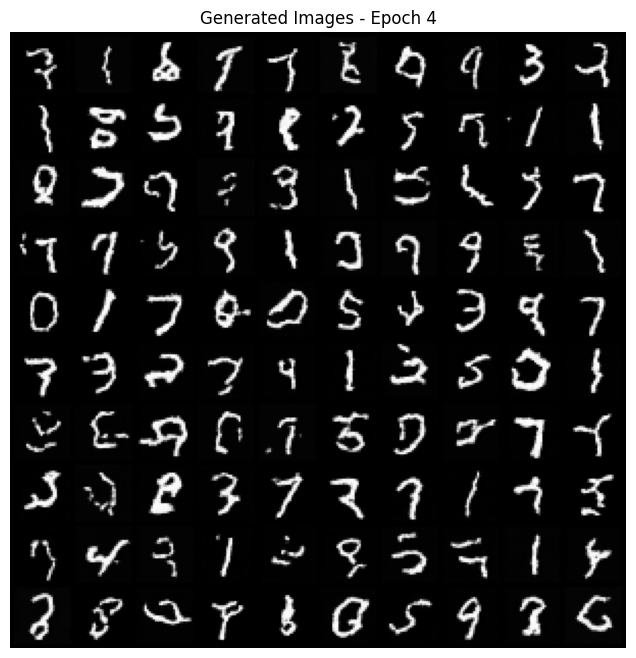

Epoch 5/20: 100%|██████████| 938/938 [06:07<00:00,  2.55it/s, loss=0.0242]


Epoch 5 finished - Avg Loss: 0.0271
Saved checkpoint: default/checkpoint_step5.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 6/20: 100%|██████████| 938/938 [06:07<00:00,  2.55it/s, loss=0.0191]


Epoch 6 finished - Avg Loss: 0.0262
Saved checkpoint: default/checkpoint_step6.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 7/20: 100%|██████████| 938/938 [06:07<00:00,  2.55it/s, loss=0.0329]


Epoch 7 finished - Avg Loss: 0.0256
Saved checkpoint: default/checkpoint_step7.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 8/20: 100%|██████████| 938/938 [06:08<00:00,  2.55it/s, loss=0.0250]


Epoch 8 finished - Avg Loss: 0.0253
Saved checkpoint: default/checkpoint_step8.pt
Updated latest checkpoint: default/latest_checkpoint.pt


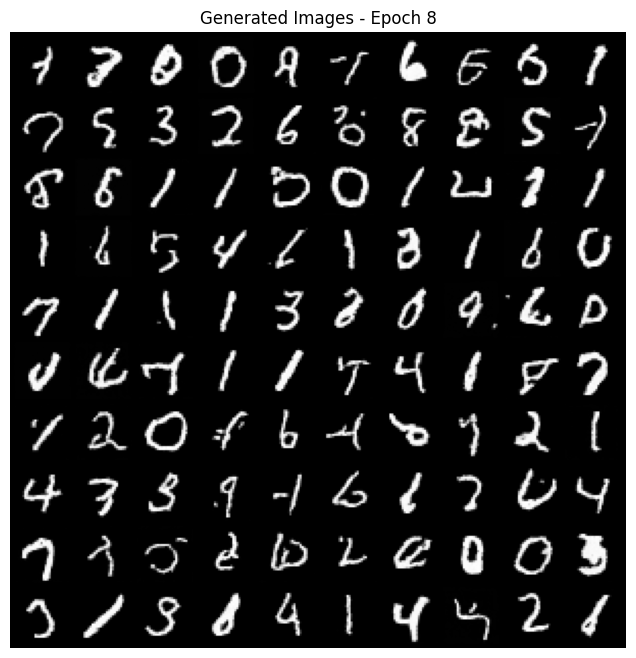

Epoch 9/20: 100%|██████████| 938/938 [06:07<00:00,  2.56it/s, loss=0.0285]


Epoch 9 finished - Avg Loss: 0.0247
Saved checkpoint: default/checkpoint_step9.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 10/20: 100%|██████████| 938/938 [06:07<00:00,  2.55it/s, loss=0.0133]


Epoch 10 finished - Avg Loss: 0.0245
Saved checkpoint: default/checkpoint_step10.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 11/20: 100%|██████████| 938/938 [06:07<00:00,  2.55it/s, loss=0.0269]


Epoch 11 finished - Avg Loss: 0.0245
Saved checkpoint: default/checkpoint_step11.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 12/20: 100%|██████████| 938/938 [06:07<00:00,  2.55it/s, loss=0.0300]


Epoch 12 finished - Avg Loss: 0.0240
Saved checkpoint: default/checkpoint_step12.pt
Updated latest checkpoint: default/latest_checkpoint.pt


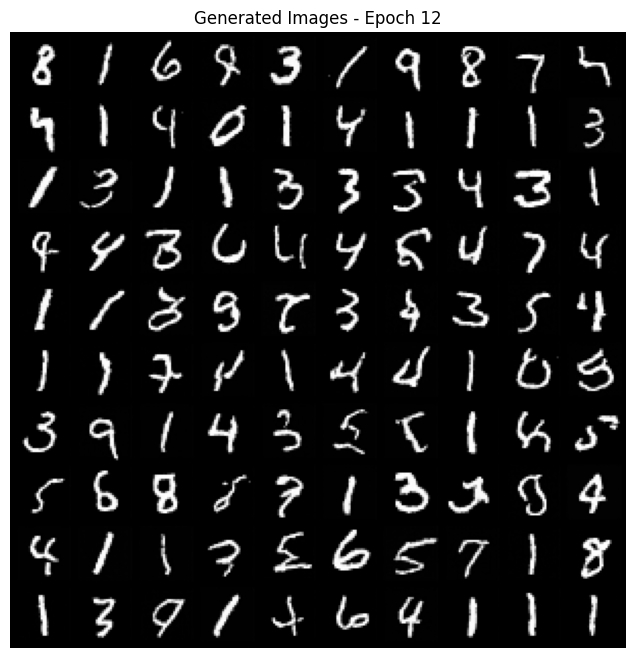

Epoch 13/20: 100%|██████████| 938/938 [06:06<00:00,  2.56it/s, loss=0.0288]


Epoch 13 finished - Avg Loss: 0.0240
Saved checkpoint: default/checkpoint_step13.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 14/20: 100%|██████████| 938/938 [06:07<00:00,  2.55it/s, loss=0.0219]


Epoch 14 finished - Avg Loss: 0.0238
Saved checkpoint: default/checkpoint_step14.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 15/20: 100%|██████████| 938/938 [06:08<00:00,  2.55it/s, loss=0.0236]


Epoch 15 finished - Avg Loss: 0.0232
Saved checkpoint: default/checkpoint_step15.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 16/20: 100%|██████████| 938/938 [06:06<00:00,  2.56it/s, loss=0.0256]


Epoch 16 finished - Avg Loss: 0.0235
Saved checkpoint: default/checkpoint_step16.pt
Updated latest checkpoint: default/latest_checkpoint.pt


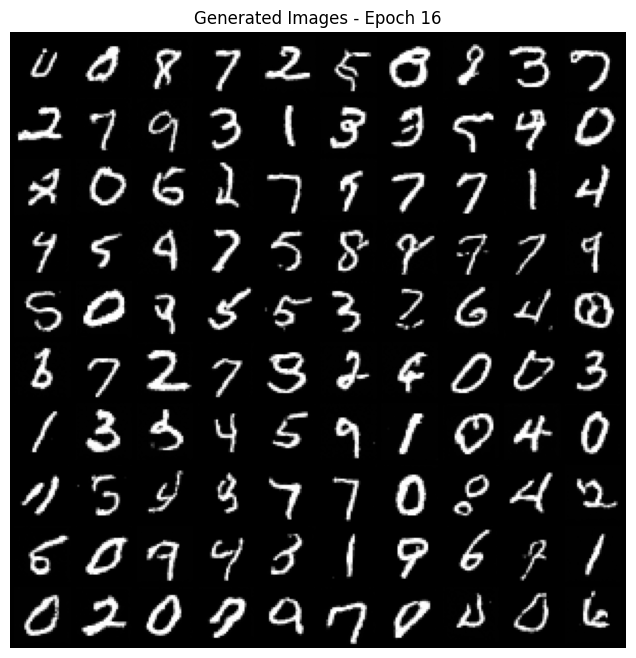

Epoch 17/20: 100%|██████████| 938/938 [06:07<00:00,  2.55it/s, loss=0.0283]


Epoch 17 finished - Avg Loss: 0.0231
Saved checkpoint: default/checkpoint_step17.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 18/20: 100%|██████████| 938/938 [06:07<00:00,  2.55it/s, loss=0.0139]


Epoch 18 finished - Avg Loss: 0.0230
Saved checkpoint: default/checkpoint_step18.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 19/20: 100%|██████████| 938/938 [06:06<00:00,  2.56it/s, loss=0.0230]


Epoch 19 finished - Avg Loss: 0.0230
Saved checkpoint: default/checkpoint_step19.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 20/20: 100%|██████████| 938/938 [06:06<00:00,  2.56it/s, loss=0.0253]


Epoch 20 finished - Avg Loss: 0.0229
Saved checkpoint: default/checkpoint_step20.pt
Updated latest checkpoint: default/latest_checkpoint.pt


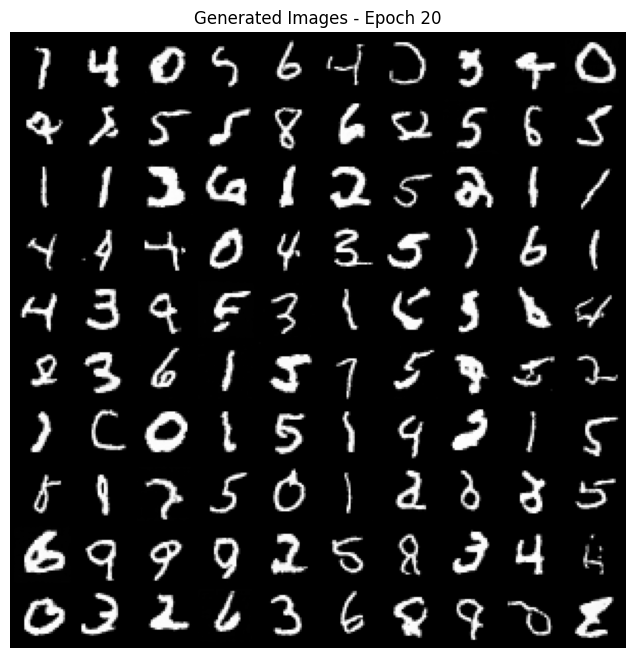

Training completed.


In [15]:
model = train(config)

Sampling: 1000it [03:43,  4.48it/s]


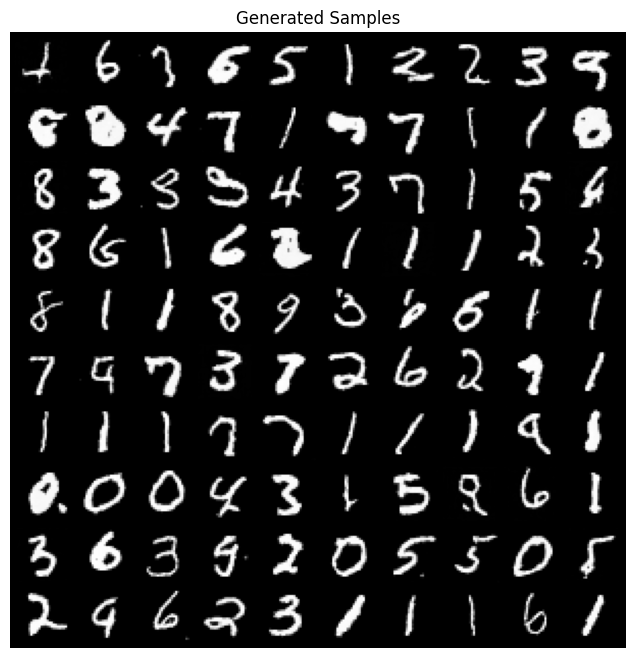

In [16]:
samples = infer(config)

## Part A - Forward Diffusion 

In [17]:
def visualize_forward_diff():
    
    diffusion_config = config['diffusion_params']

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: (2 * x) - 1)
    ])
    
    train_dataset = torchvision.datasets.MNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=config['train_params']['batch_size'],
        shuffle=True,
        num_workers=2,
        pin_memory=True if device.type == 'cuda' else False
    )
    
    images, _ = next(iter(train_loader))
    original_image = images[0:1].to(device) 
    
    noise = torch.randn_like(original_image).to(device)
    
    num_timesteps = diffusion_config['num_timesteps']
    timesteps = torch.linspace(0, num_timesteps - 1, 10).long().to(device)
    scheduler = LinearNoiseScheduler(
        num_timesteps=diffusion_config['num_timesteps'],
        beta_start=diffusion_config['beta_start'],
        beta_end=diffusion_config['beta_end']
    )
    plt.figure(figsize=(20, 3))
    for i, t in enumerate(timesteps):
        t_tensor = t.unsqueeze(0)
        
        noisy_image = scheduler.add_noise(original_image, noise, t_tensor)
        
        img_vis = torch.clamp(noisy_image.squeeze(), -1.0, 1.0).detach().cpu()
        img_vis = (img_vis + 1) / 2 
        
        plt.subplot(1, 10, i + 1)
        plt.imshow(img_vis, cmap='gray')
        plt.title(f"t = {t.item()}")
        plt.axis('off')
        
    plt.suptitle("Forward Diffusion Process across 10 Timesteps", fontsize=16)
    plt.tight_layout()
    plt.show()

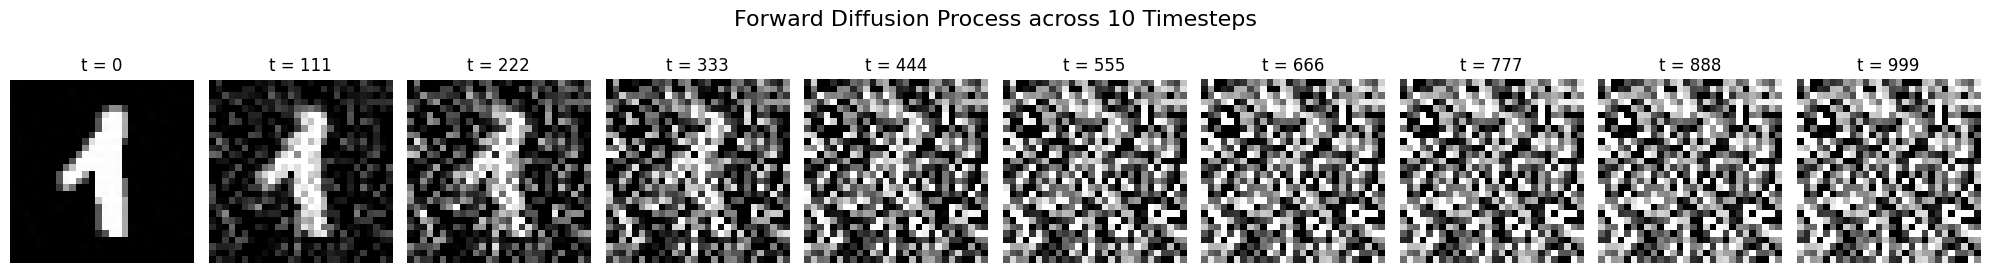

In [18]:
visualize_forward_diff()

## Part B - Hybrid Loss

In [19]:
def hybrid_noise_x0_loss(noise_pred, noise, noisy_images, clean_images, t, scheduler, lambda_weight=0.1):
    loss_eps = torch.nn.functional.mse_loss(noise_pred, noise)
    
    device = clean_images.device
    
    sqrt_alpha_bar = scheduler.sqrt_alpha_cum_prod.to(device)[t].view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar = scheduler.sqrt_one_minus_alpha_cum_prod.to(device)[t].view(-1, 1, 1, 1)
    
    pred_x0 = (noisy_images - sqrt_one_minus_alpha_bar * noise_pred) / sqrt_alpha_bar
    
    loss_x0 = torch.nn.functional.mse_loss(pred_x0, clean_images)
    
    return loss_eps + (lambda_weight * loss_x0)

In [20]:
!rm -r /kaggle/working/default

Using device: cuda
Checkpoint directory: default
Latest checkpoint path: default/latest_checkpoint.pt
No checkpoint found. Starting training from scratch.


Epoch 1/20: 100%|██████████| 938/938 [06:06<00:00,  2.56it/s, loss=0.8627]


Epoch 1 finished - Avg Loss: 8.4620
Saved checkpoint: default/checkpoint_step1.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 2/20: 100%|██████████| 938/938 [06:05<00:00,  2.56it/s, loss=0.3222]


Epoch 2 finished - Avg Loss: 0.6233
Saved checkpoint: default/checkpoint_step2.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 3/20: 100%|██████████| 938/938 [06:04<00:00,  2.57it/s, loss=0.2456]


Epoch 3 finished - Avg Loss: 0.3422
Saved checkpoint: default/checkpoint_step3.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 4/20: 100%|██████████| 938/938 [06:06<00:00,  2.56it/s, loss=0.3660]


Epoch 4 finished - Avg Loss: 0.2240
Saved checkpoint: default/checkpoint_step4.pt
Updated latest checkpoint: default/latest_checkpoint.pt


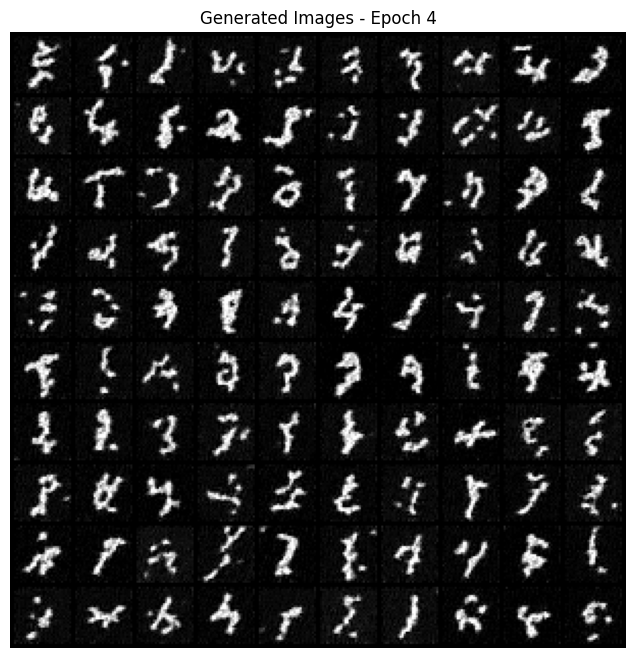

Epoch 5/20: 100%|██████████| 938/938 [06:06<00:00,  2.56it/s, loss=0.1163]


Epoch 5 finished - Avg Loss: 0.1625
Saved checkpoint: default/checkpoint_step5.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 6/20: 100%|██████████| 938/938 [06:06<00:00,  2.56it/s, loss=0.1115]


Epoch 6 finished - Avg Loss: 0.1269
Saved checkpoint: default/checkpoint_step6.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 7/20: 100%|██████████| 938/938 [06:05<00:00,  2.56it/s, loss=0.0575]


Epoch 7 finished - Avg Loss: 0.0989
Saved checkpoint: default/checkpoint_step7.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 8/20: 100%|██████████| 938/938 [06:05<00:00,  2.56it/s, loss=0.1266]


Epoch 8 finished - Avg Loss: 0.0865
Saved checkpoint: default/checkpoint_step8.pt
Updated latest checkpoint: default/latest_checkpoint.pt


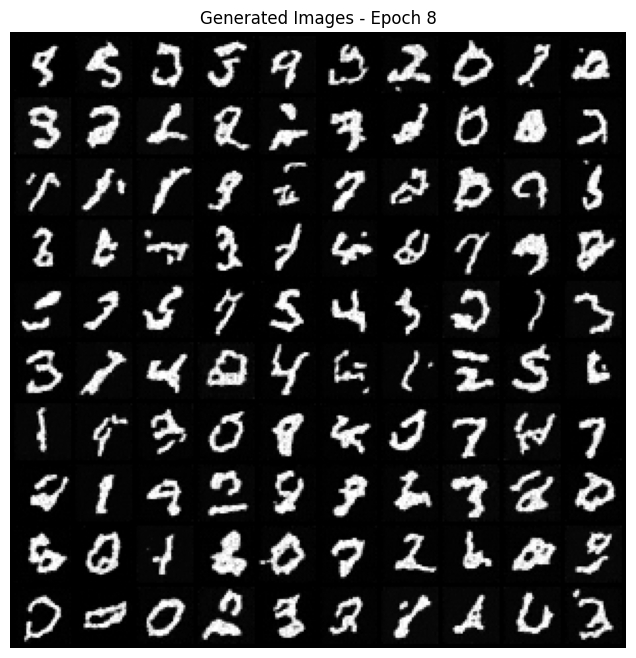

Epoch 9/20: 100%|██████████| 938/938 [06:06<00:00,  2.56it/s, loss=0.0673]


Epoch 9 finished - Avg Loss: 0.0801
Saved checkpoint: default/checkpoint_step9.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 10/20: 100%|██████████| 938/938 [06:05<00:00,  2.57it/s, loss=0.0624]


Epoch 10 finished - Avg Loss: 0.0710
Saved checkpoint: default/checkpoint_step10.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 11/20: 100%|██████████| 938/938 [06:04<00:00,  2.58it/s, loss=0.0447]


Epoch 11 finished - Avg Loss: 0.0713
Saved checkpoint: default/checkpoint_step11.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 12/20: 100%|██████████| 938/938 [06:05<00:00,  2.57it/s, loss=0.0603]


Epoch 12 finished - Avg Loss: 0.0615
Saved checkpoint: default/checkpoint_step12.pt
Updated latest checkpoint: default/latest_checkpoint.pt


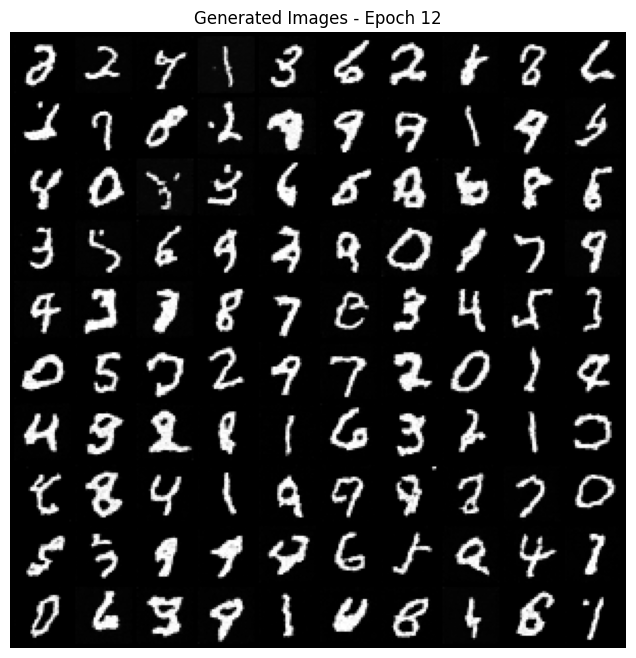

Epoch 13/20: 100%|██████████| 938/938 [06:05<00:00,  2.57it/s, loss=0.0505]


Epoch 13 finished - Avg Loss: 0.0632
Saved checkpoint: default/checkpoint_step13.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 14/20: 100%|██████████| 938/938 [06:03<00:00,  2.58it/s, loss=0.0529]


Epoch 14 finished - Avg Loss: 0.0582
Saved checkpoint: default/checkpoint_step14.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 15/20: 100%|██████████| 938/938 [06:04<00:00,  2.57it/s, loss=0.0592]


Epoch 15 finished - Avg Loss: 0.0556
Saved checkpoint: default/checkpoint_step15.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 16/20: 100%|██████████| 938/938 [06:05<00:00,  2.57it/s, loss=0.0560]


Epoch 16 finished - Avg Loss: 0.0559
Saved checkpoint: default/checkpoint_step16.pt
Updated latest checkpoint: default/latest_checkpoint.pt


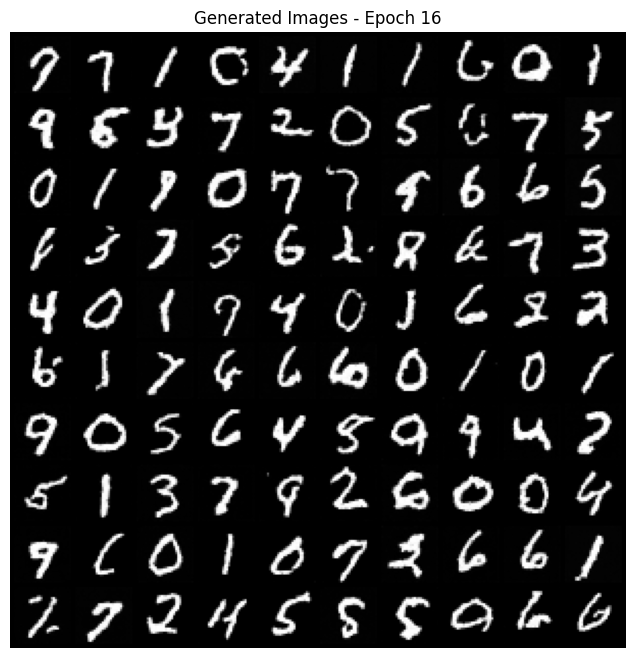

Epoch 17/20: 100%|██████████| 938/938 [06:04<00:00,  2.58it/s, loss=0.0501]


Epoch 17 finished - Avg Loss: 0.0537
Saved checkpoint: default/checkpoint_step17.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 18/20: 100%|██████████| 938/938 [06:04<00:00,  2.57it/s, loss=0.0401]


Epoch 18 finished - Avg Loss: 0.0554
Saved checkpoint: default/checkpoint_step18.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 19/20: 100%|██████████| 938/938 [06:05<00:00,  2.57it/s, loss=0.0531]


Epoch 19 finished - Avg Loss: 0.0496
Saved checkpoint: default/checkpoint_step19.pt
Updated latest checkpoint: default/latest_checkpoint.pt


Epoch 20/20: 100%|██████████| 938/938 [06:04<00:00,  2.57it/s, loss=0.0524]


Epoch 20 finished - Avg Loss: 0.0488
Saved checkpoint: default/checkpoint_step20.pt
Updated latest checkpoint: default/latest_checkpoint.pt


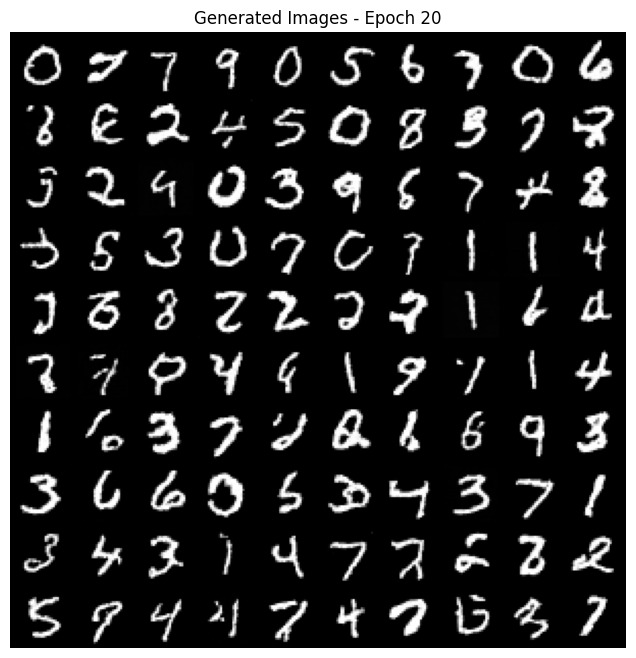

Training completed.


In [21]:
model = train(config, is_hybrid = True)

Sampling: 1000it [03:43,  4.47it/s]


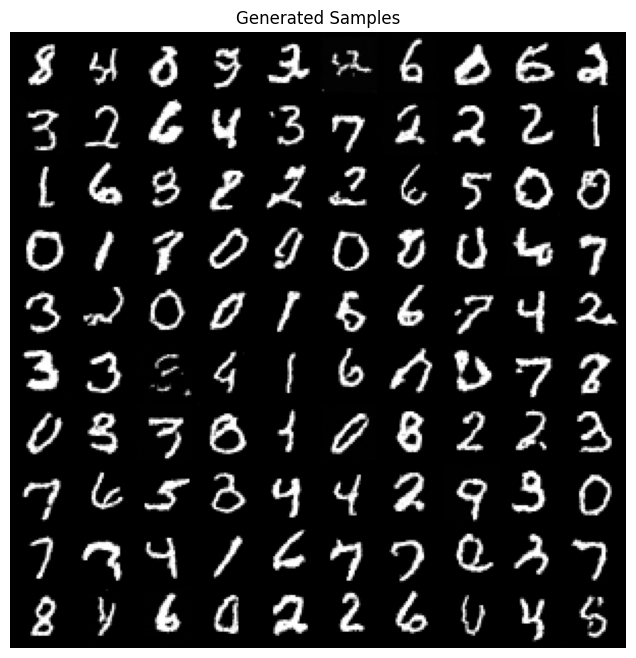

In [22]:
samples = infer(config)

## New Loss
The new hybrid loss function penalizes L2 differences with the original image in the generation process. This has resulted in a generally higher quality in generated images but the cost of using this loss function is that the variety will be less for the overall generation model.

## Part C - DDIM Sampler

In [23]:
class DDIMSampler:
    def __init__(self, num_train_timesteps, beta_start, beta_end):
        self.num_train_timesteps = num_train_timesteps
        self.betas = torch.linspace(beta_start, beta_end, num_train_timesteps)
        self.alphas = 1. - self.betas
        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)

    def sample(self, model, shape, device, num_inference_steps=50, eta=0.0):

        model.eval()

        step_ratio = self.num_train_timesteps // num_inference_steps
        timesteps = (np.arange(0, num_inference_steps) * step_ratio).round()[::-1].copy().astype(np.int64)
        timesteps = torch.from_numpy(timesteps).to(device)

        xt = torch.randn(shape, device=device)

        with torch.no_grad():
            for i, t in enumerate(tqdm(timesteps, desc=f"DDIM Sampling ({num_inference_steps} steps)")):
                t_batch = torch.full((shape[0],), t, device=device, dtype=torch.long)

                noise_pred = model(xt, t_batch)

                alpha_prod_t = self.alpha_cum_prod.to(device)[t]
                if i < len(timesteps) - 1:
                    alpha_prod_t_prev = self.alpha_cum_prod.to(device)[timesteps[i + 1]]
                else:
                    alpha_prod_t_prev = torch.tensor(1.0).to(device)

                pred_x0 = (xt - torch.sqrt(1 - alpha_prod_t) * noise_pred) / torch.sqrt(alpha_prod_t)
                pred_x0 = torch.clamp(pred_x0, -1., 1.)

                variance = (1 - alpha_prod_t_prev) / (1 - alpha_prod_t) * (1 - alpha_prod_t / alpha_prod_t_prev)
                std_dev_t = eta * torch.sqrt(variance)

                pred_dir_xt = torch.sqrt(1 - alpha_prod_t_prev - std_dev_t**2) * noise_pred

                noise = torch.randn_like(xt) if t > 0 else torch.zeros_like(xt)

                xt = torch.sqrt(alpha_prod_t_prev) * pred_x0 + pred_dir_xt + std_dev_t * noise

        model.train()
        return xt

Generating with 50 Steps (Deterministic DDIM)...


DDIM Sampling (50 steps): 100%|██████████| 50/50 [00:03<00:00, 14.66it/s]


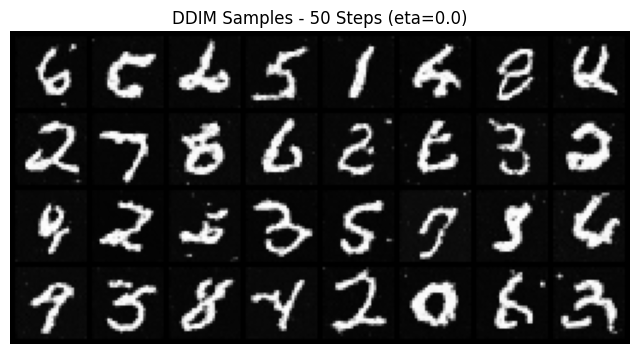

Generating with 200 Steps (Deterministic DDIM)...


DDIM Sampling (200 steps): 100%|██████████| 200/200 [00:13<00:00, 14.38it/s]


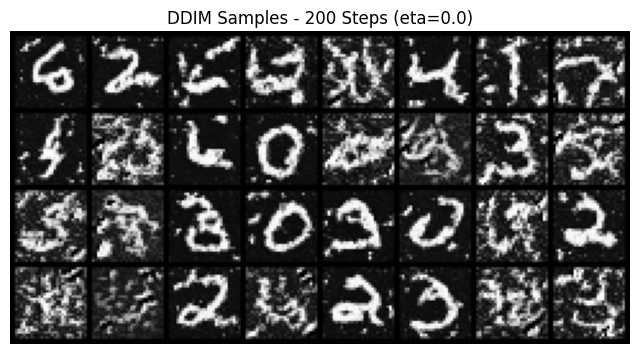

In [24]:
ddim_sampler = DDIMSampler(
    num_train_timesteps=config['diffusion_params']['num_timesteps'],
    beta_start=config['diffusion_params']['beta_start'],
    beta_end=config['diffusion_params']['beta_end']
)

sample_shape = (
    32,
    config['model_params']['im_channels'],
    config['model_params']['im_size'],
    config['model_params']['im_size']
)

print("Generating with 50 Steps (Deterministic DDIM)...")
ddim_samples_50 = ddim_sampler.sample(model, sample_shape, device, num_inference_steps=50, eta=0.0)
show_tensor_images(ddim_samples_50, nrow=8, title="DDIM Samples - 50 Steps (eta=0.0)")

print("Generating with 200 Steps (Deterministic DDIM)...")
ddim_samples_200 = ddim_sampler.sample(model, sample_shape, device, num_inference_steps=200, eta=0.0)
show_tensor_images(ddim_samples_200, nrow=8, title="DDIM Samples - 200 Steps (eta=0.0)")

## DDIM Sampling
The sampler uses the same model that was trained in the hybrid loss but the generation quality rivals the original model with only 50 samples with a minor change in the sampling strategy.